# Qualitative Synthetic Examples

This notebook builds eight synthetic time series for qualitative inspection and runs `LinearPFN` inference on them.

Each series has length `1000` with the evaluation split:

- context: first `808` points
- query: next `96` points
- target: last `96` points


In [1]:
import torch
from utils.qualitative_examples import *

set_qualitative_plot_style()
torch.set_grad_enabled(False)


In [2]:
split = SplitConfig(series_len=1000, lookback=96, horizon=96)
SEED = 7

torch.manual_seed(SEED)
np.random.seed(SEED)

print(split.as_dict())


{'series_len': 1000, 'context': (0, 808), 'query': (808, 904), 'target': (904, 1000)}


In [3]:
series_specs = default_series_specs()
len(series_specs)

8

In [4]:
examples, summary = generate_qualitative_examples(series_specs=series_specs, split=split, seed=SEED)
summary

,name,notes,resolution,harmonics,trend_lin,trend_exp,noise_scale,additive
0,1. Easy trend + seasonality,"1. Mild linear trend, single seasonal componen...",8.0,"(1, 1, 1)",0.003,1.000,0.02,True
1,2. Stronger seasonality,"2. Same basic pattern, richer seasonal structure.",8.0,"(1, 1, 2)",0.003,1.000,0.03,True
2,3. More harmonics,3. More complex seasonality and increased noise.,8.0,"(1, 3, 5)",0.003,1.000,0.04,True
3,4. Larger trend scale,4. Trend dominates more of the trajectory.,8.0,"(1, 3, 5)",0.007,1.000,0.05,True
4,5. Exponential drift,5. New exponential trend growth on top of the ...,8.0,"(1, 3, 5)",0.006,1.010,0.06,True
5,6. Multiplicative interaction,"6. Trend and seasonality interact,\nchanging s...",8.0,"(2, 4, 5)",0.007,1.015,0.07,False
6,7. Moderate noise,7. Stronger stochastic variation.,7.0,"(2, 4, 6)",0.008,1.020,0.14,False
7,8. Hardest mixed case,"8. Higher harmonics, stronger drift,\nlower ef...",5.5,"(3, 5, 7)",0.010,1.030,0.24,False


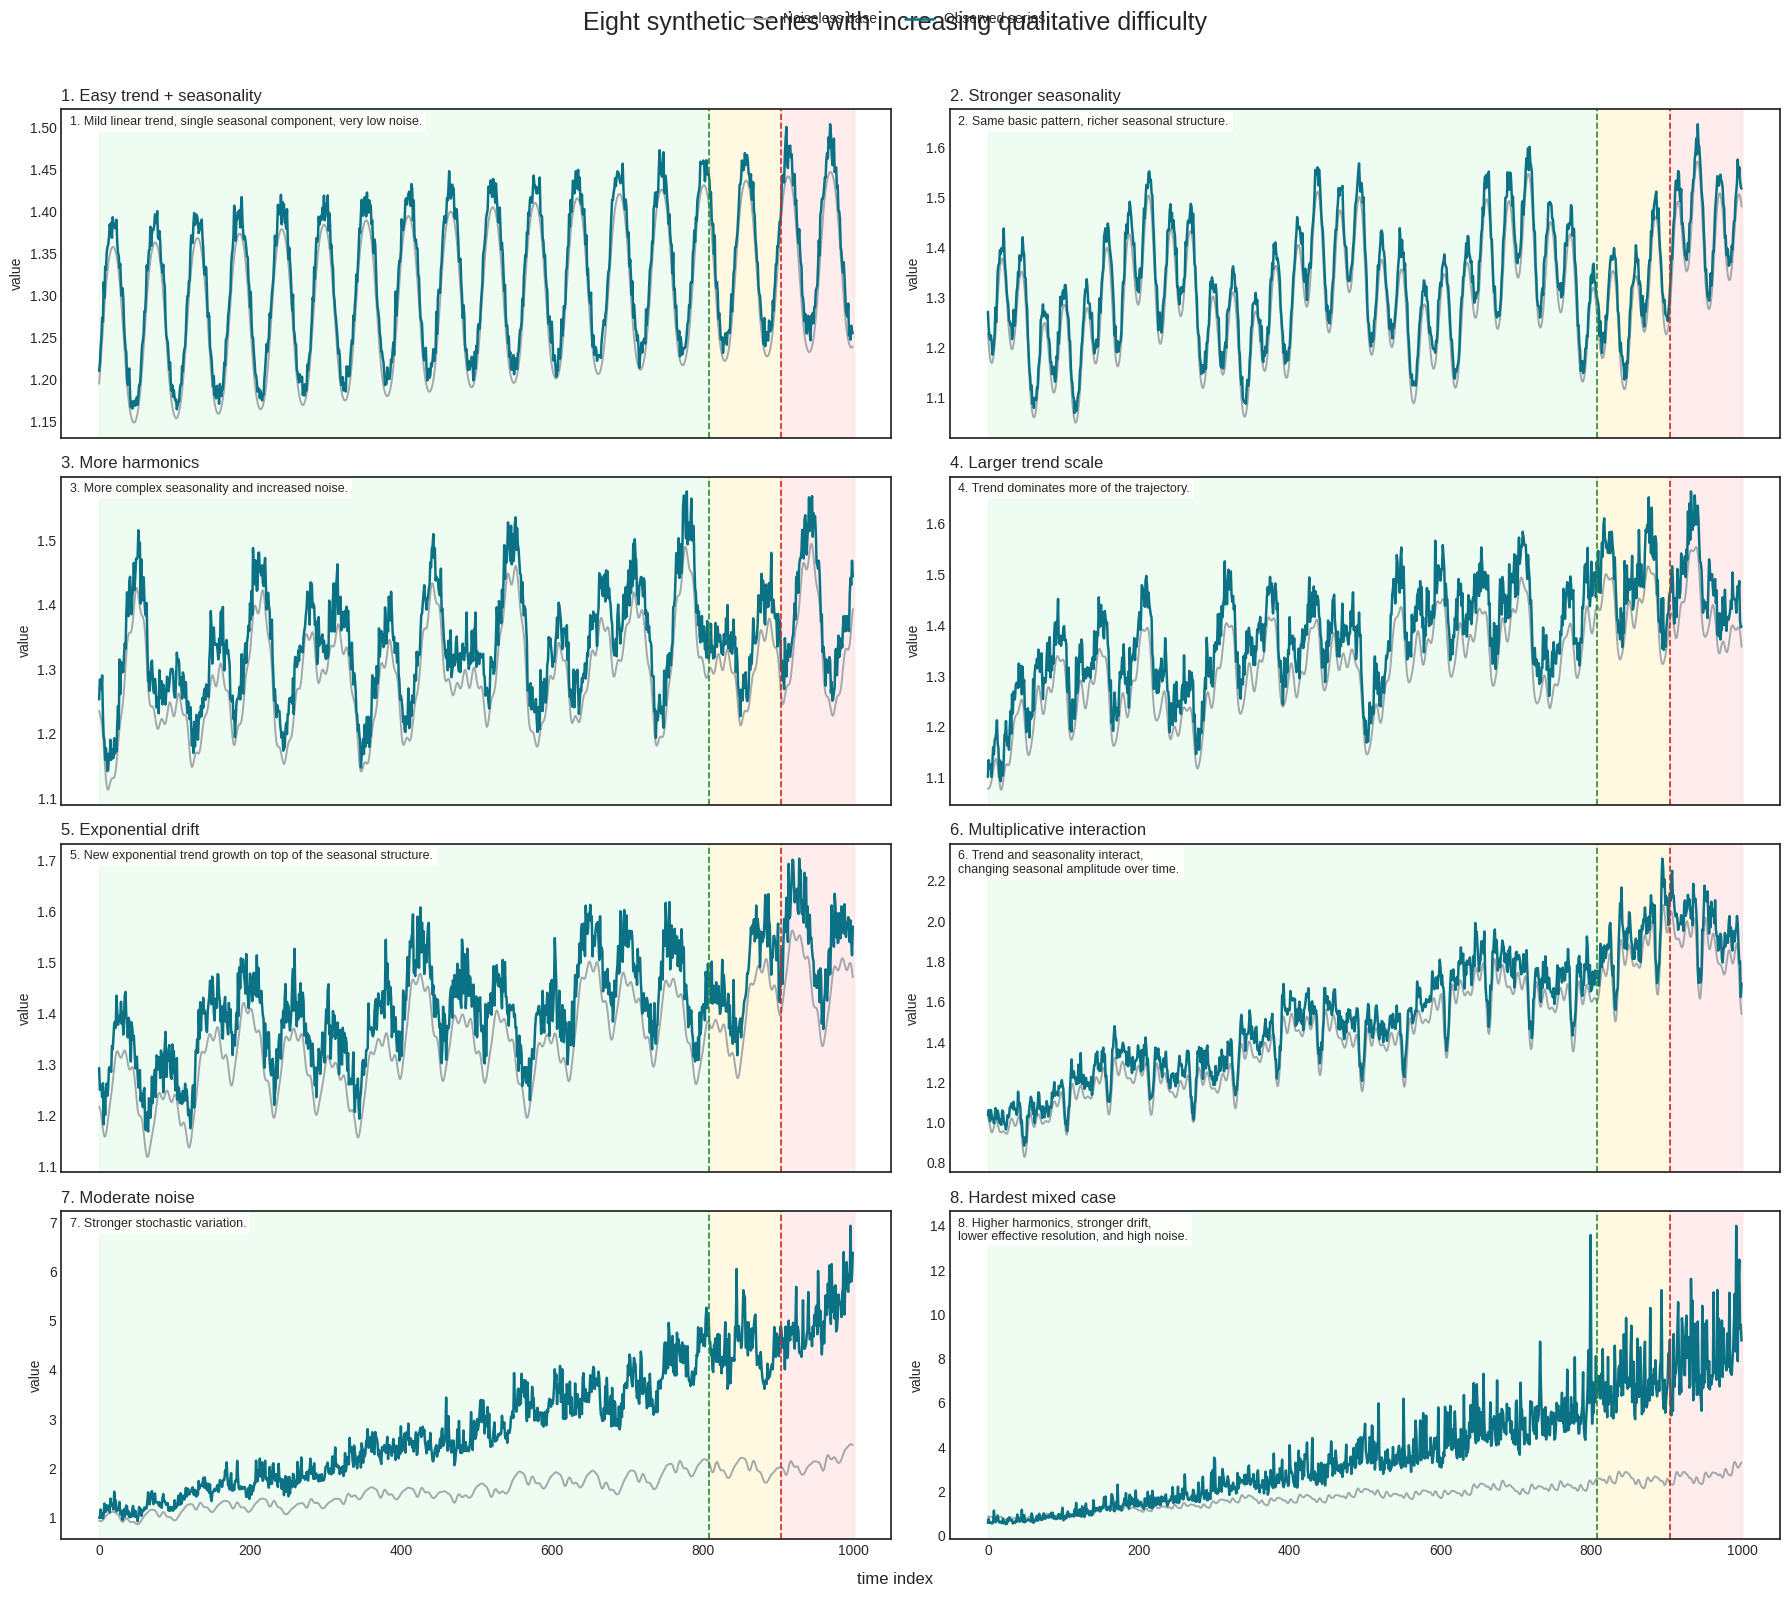

In [5]:
fig, axes = plot_examples_overview(examples, split=split)
plt.show()

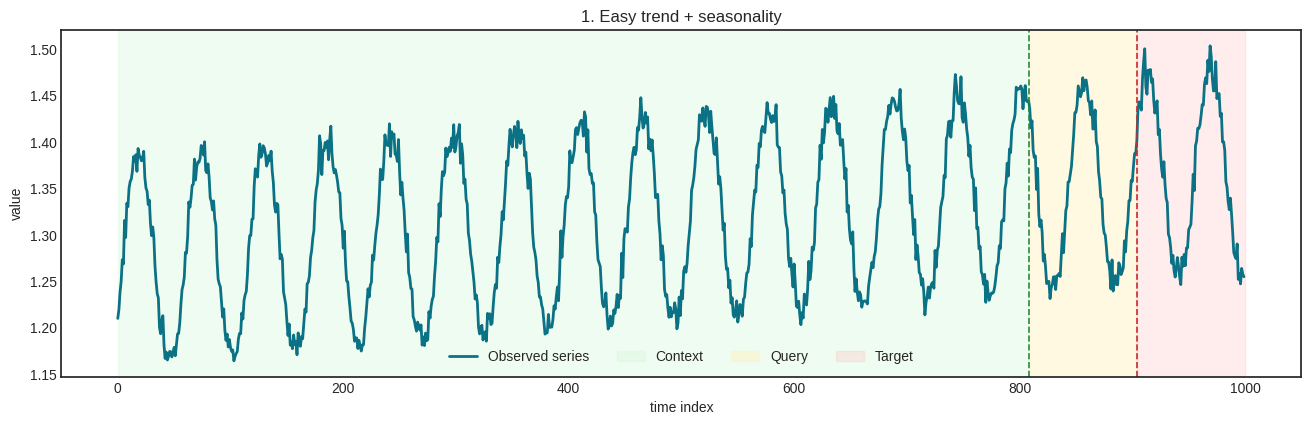

In [6]:
focus_idx = 0
example = examples[focus_idx]

fig, ax = plot_single_example(example, split=split)
plt.show()

Loading model from Hugging Face Hub...
longthangvu/LinearPFN
/home/lvu/.cache/huggingface/hub/models--longthangvu--LinearPFN/snapshots/cda879138f2d7988e0f63b27bf409c04ec4111c0/best_model.pt
{'L': 96, 'H': 96, 'dropout': 0.1, 'd': 512, 'd_ff': 2048, 'L_blk': 10, 'n_heads': 8}


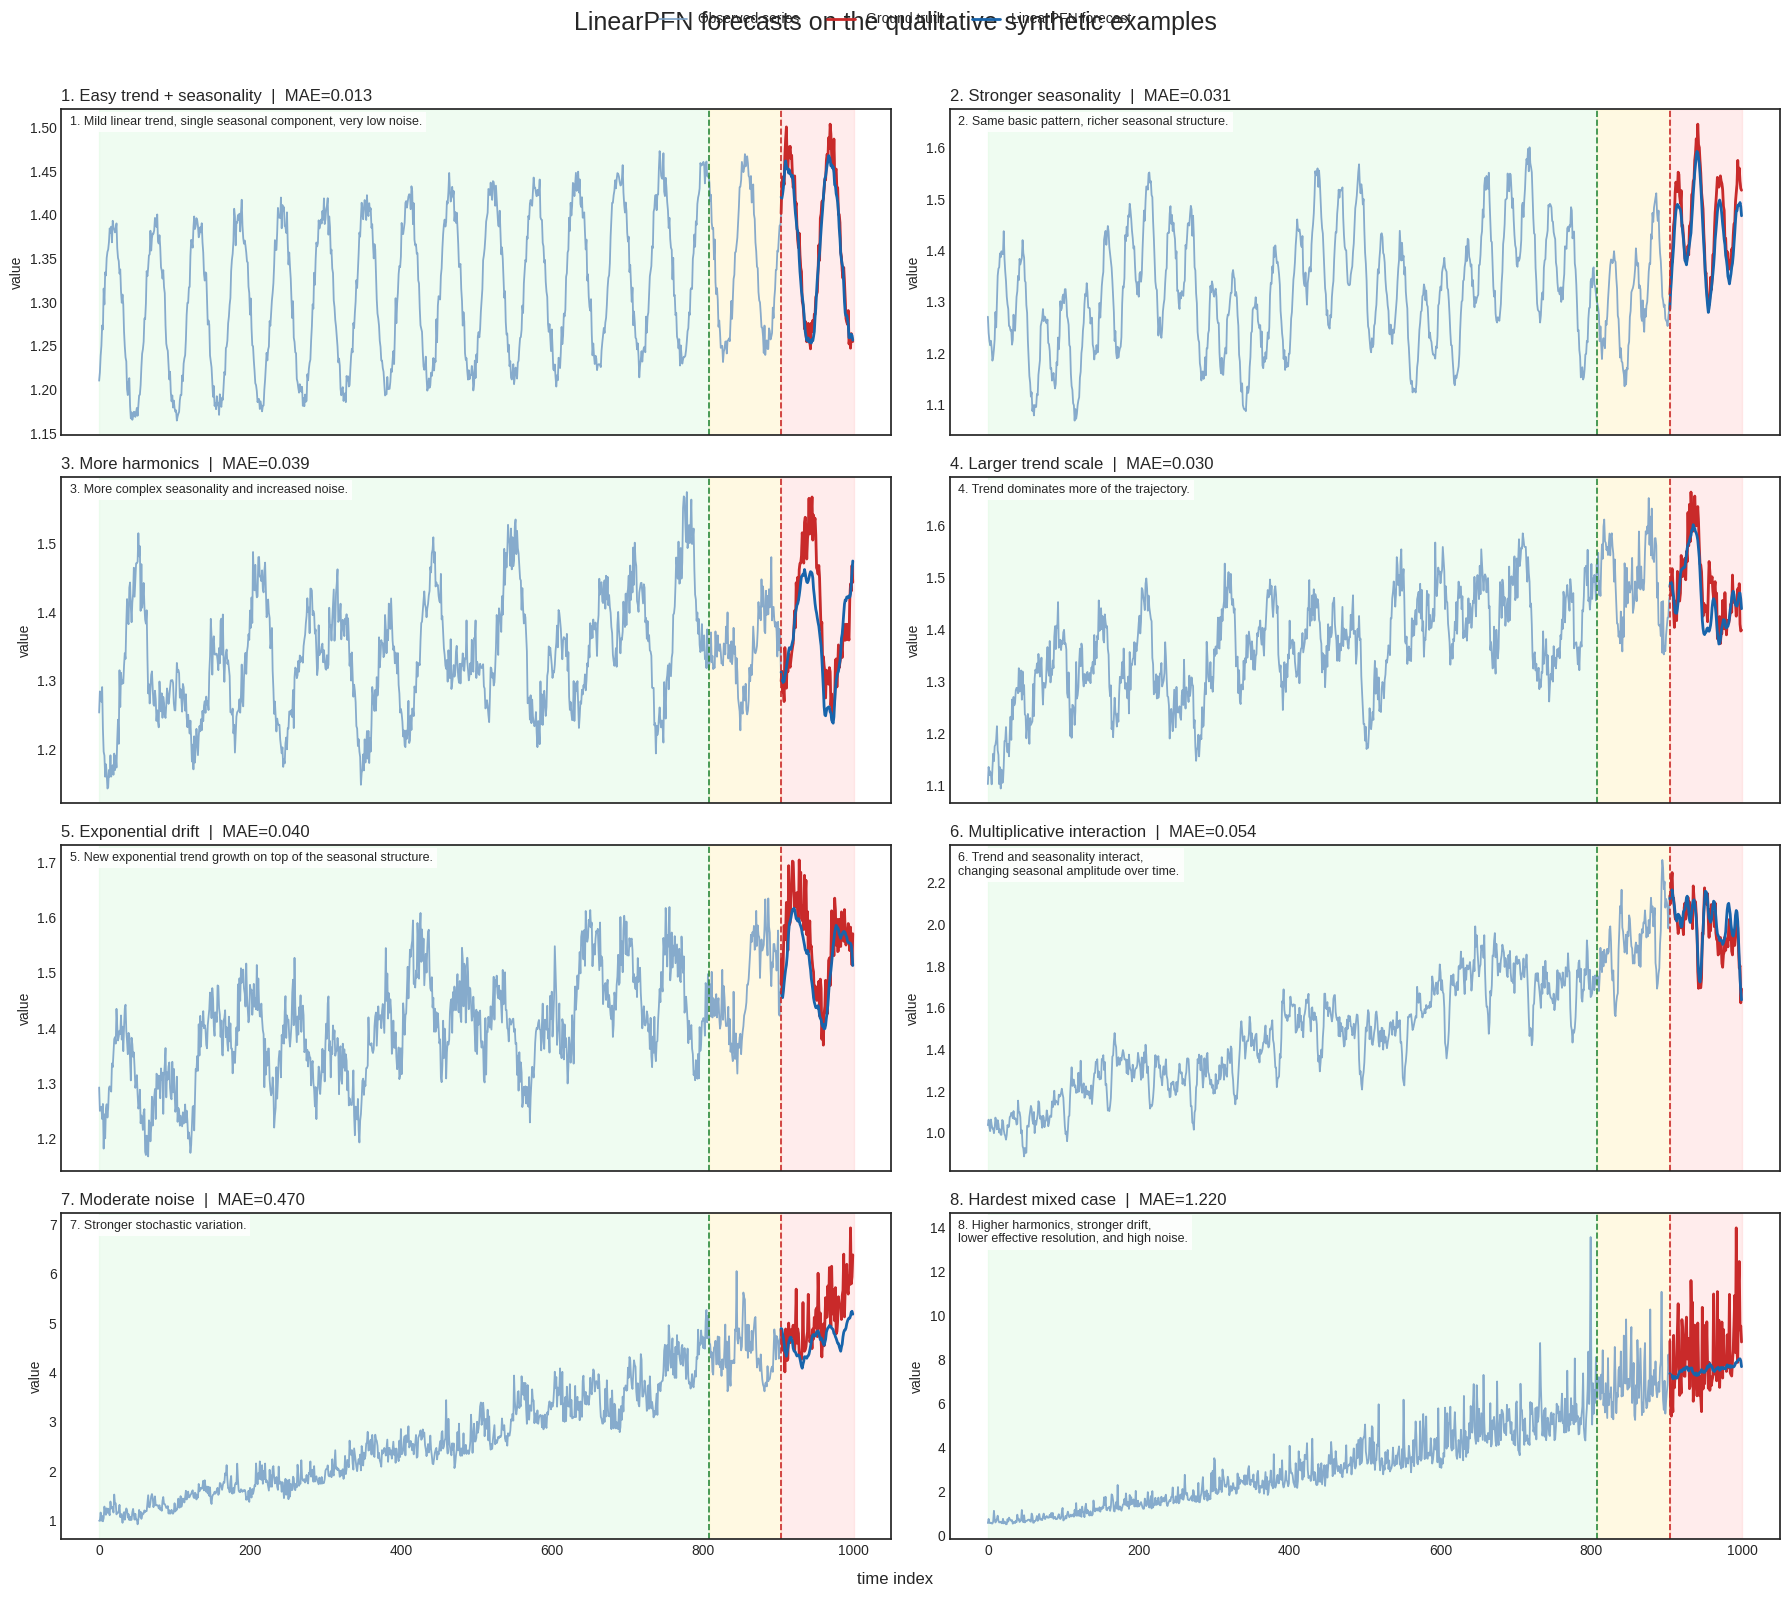

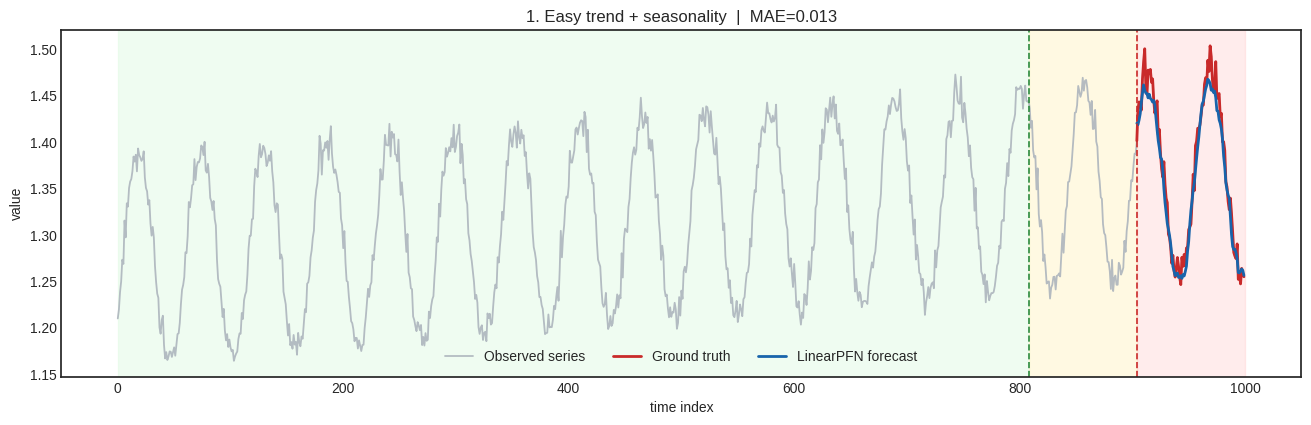

In [7]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# if hasattr(torch.backends, "mps") and torch.backends.mps.is_available(): device = torch.device("mps")
forecast_results = run_linearpfn_on_examples(examples, split=split, num_context=100, device=device)

pd.DataFrame({
    "name": [result["name"] for result in forecast_results],
    "mae": [result["mae"] for result in forecast_results],
}).sort_values("name")

fig, axes = plot_forecast_overview(forecast_results, split=split)
plt.show()

fig, ax = plot_forecast_detail(forecast_results[0], split=split)
plt.show()


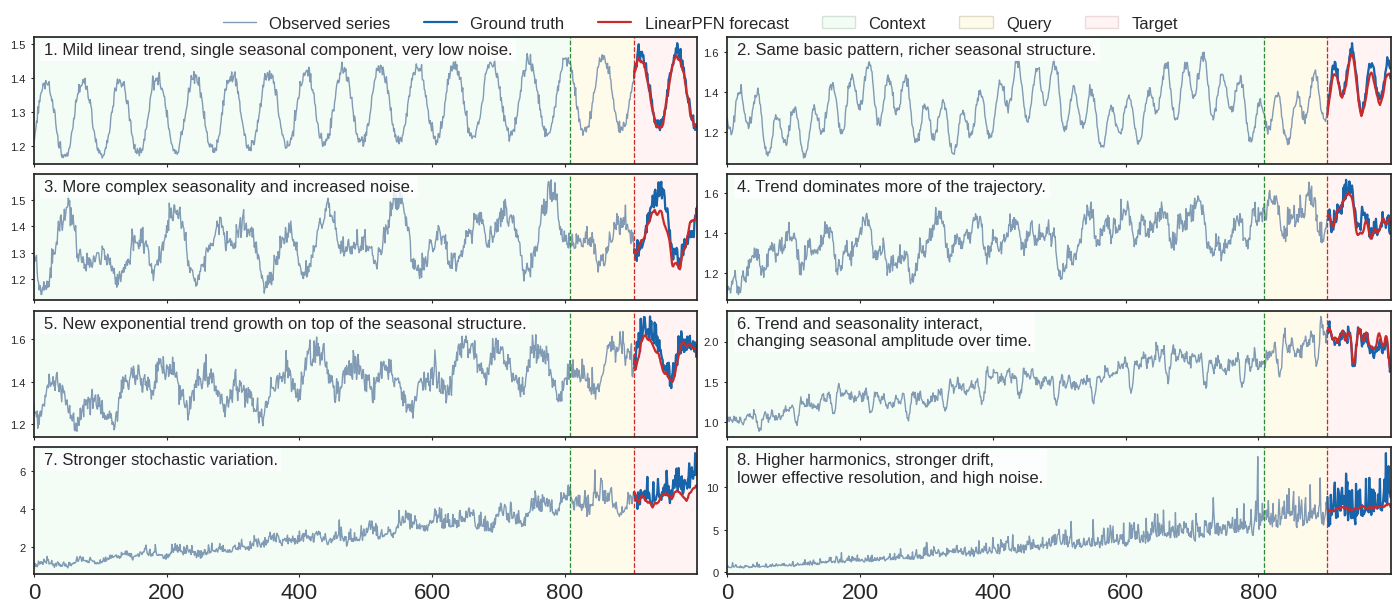

In [8]:
fig, axes = plot_forecast_paper_figure(forecast_results, split=split)
plt.savefig("qualitative_examples.pdf", bbox_inches='tight')
plt.show()
